# Get OT/PT times from MIMIC chartevents
## Don't run as it takes lots of time!!!

In [ ]:
import pandas as pd
import glob

chunk_path = "/gpfs/gibbs/pi/zhao_yize/jl4286/chartevents/chunks/*.csv"

ot_records = []
pt_records = []

file_list = glob.glob(chunk_path)
print(f"Found {len(file_list)} chunk files. Processing...")

for i, file in enumerate(file_list):
    df = pd.read_csv(file) 

    # Filter for OT and PT consults
    ot_df = df[(df["itemid"] == 225135) & (df["value"] == "OT")]
    pt_df = df[(df["itemid"] == 225135) & (df["value"] == "PT")]

    if not ot_df.empty:
        ot_records.append(ot_df)
    if not pt_df.empty:
        pt_records.append(pt_df)

In [ ]:
if ot_records:
    all_ot = pd.concat(ot_records, ignore_index=True)
    all_ot.to_csv("/gpfs/gibbs/project/jain_snigdha/jl4286/OT_PT_intermediate_data/ot_consult.csv", index=False)
    print("Saved OT records to ot_consult.csv")

if pt_records:
    all_pt = pd.concat(pt_records, ignore_index=True)
    all_pt.to_csv("/gpfs/gibbs/project/jain_snigdha/jl4286/OT_PT_intermediate_data/pt_consult.csv", index=False)
    print("Saved PT records to pt_consult.csv")

# Merge the first post_imv OT/PT time into final_df

In [1]:
import pandas as pd

ot_df = pd.read_csv("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/ot_consult.csv", parse_dates=["ot_time"])
pt_df = pd.read_csv("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/pt_consult.csv", parse_dates=["pt_time"])

In [2]:
ot_df.head()

,subject_id,hadm_id,stay_id,caregiver_id,ot_time,storetime,itemid,value,valuenum,valueuom,warning,patient_id
0,19728994,24060875,30033179,17762.0,2157-08-06 06:51:00,2157-08-06 06:55:00,225135,OT,NaN,NaN,0.0,19728994
1,13972513,22100555,30479593,60065.0,2206-04-25 18:05:00,2206-04-25 18:07:00,225135,OT,NaN,NaN,0.0,13972513
2,13972513,23459760,33155916,32954.0,2206-04-08 01:57:00,2206-04-08 02:01:00,225135,OT,NaN,NaN,0.0,13972513
3,10230936,20449497,34698361,26099.0,2111-08-04 22:27:00,2111-08-04 22:30:00,225135,OT,NaN,NaN,0.0,10230936
4,10230936,20449497,34698361,26099.0,2111-08-05 00:27:00,2111-08-05 00:28:00,225135,OT,NaN,NaN,0.0,10230936


In [3]:
final_df = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/mobilization_output/intermediate/cohort_all_ids_w_outcome.parquet")

In [4]:
final_df.head()

,patient_id,hospitalization_id,encounter_block,discharge_category,discharge_dttm,block_vent_start_dttm,block_vent_end_dttm,block_first_vital_dttm,block_last_vital_dttm,death_dttm,final_outcome_dttm,is_dead
0,10001884,26184834,97,Expired,2131-01-20 05:15:00-05:00,2131-01-11 04:00:00-05:00,2131-01-19 19:59:59-05:00,2131-01-11 04:20:00-05:00,2131-01-20 04:19:00-05:00,2131-01-20 05:15:00-05:00,2131-01-20 04:19:00-05:00,1
1,10002013,23581541,104,Home,2160-05-23 13:30:00-05:00,2160-05-18 14:00:00-05:00,2160-05-18 20:59:59-05:00,2160-05-18 10:00:00-05:00,2160-05-19 16:00:00-05:00,NaT,2160-05-19 16:00:00-05:00,0
2,10002114,27793700,118,Home,2162-03-04 15:16:00-05:00,2162-02-17 23:00:00-05:00,2162-02-19 21:59:59-05:00,2162-02-17 22:33:00-05:00,2162-02-20 19:06:00-05:00,NaT,2162-02-20 19:06:00-05:00,0
3,10002428,28662225,141,Skilled Nursing Facility (SNF),2156-04-29 16:26:00-05:00,2156-04-19 20:00:00-05:00,2156-04-22 16:59:59-05:00,2156-04-12 16:24:00-05:00,2156-04-26 18:00:00-05:00,NaT,2156-04-26 18:00:00-05:00,0
4,10002428,23473524,143,Long Term Care Hospital (LTACH),2156-05-22 14:16:00-05:00,2156-05-11 16:00:00-05:00,2156-05-21 04:59:59-05:00,2156-05-11 14:49:00-05:00,2156-05-22 13:00:00-05:00,NaT,2156-05-22 13:00:00-05:00,0


In [5]:
final_df.columns.tolist()

['patient_id',
 'hospitalization_id',
 'encounter_block',
 'discharge_category',
 'discharge_dttm',
 'block_vent_start_dttm',
 'block_vent_end_dttm',
 'block_first_vital_dttm',
 'block_last_vital_dttm',
 'death_dttm',
 'final_outcome_dttm',
 'is_dead']

In [6]:
def _ensure_datetime_naive(s: pd.Series) -> pd.Series:
    """Parse to datetime; if tz-aware, drop tz to make naive."""
    s = pd.to_datetime(s, errors='coerce')
    try:
        return s.dt.tz_localize(None)
    except TypeError:
        return s

def _prep_orders(df: pd.DataFrame, *, discipline: str) -> pd.DataFrame:
    """
    Return standardized orders with columns:
      ['patient_id','hospitalization_id','order_dttm','discipline']
    Uses ot_time or pt_time.
    """
    time_cols_pref = ['ot_time', 'pt_time']
    time_col = next((c for c in time_cols_pref if c in df.columns), None)

    tmp = df.copy()

    if 'hospitalization_id' not in tmp.columns and 'hadm_id' in tmp.columns:
        tmp = tmp.rename(columns={'hadm_id': 'hospitalization_id'})

    keep_cols = [c for c in ['patient_id', 'hospitalization_id', time_col] if c in tmp.columns]
    out = tmp[keep_cols].copy()

    out['order_dttm'] = pd.to_datetime(out[time_col], errors='coerce')
    out['hospitalization_id'] = out['hospitalization_id'].astype(str)
    out['patient_id'] = out['patient_id'].astype(str)
    out = out.drop(columns=[time_col])
    out['discipline'] = discipline

    return out

In [7]:
ot_orders = _prep_orders(ot_df, discipline='OT')
pt_orders = _prep_orders(pt_df, discipline='PT')
orders = pd.concat([ot_orders, pt_orders], ignore_index=True)
orders.head(10)

,patient_id,hospitalization_id,order_dttm,discipline
0,19728994,24060875,2157-08-06 06:51:00,OT
1,13972513,22100555,2206-04-25 18:05:00,OT
2,13972513,23459760,2206-04-08 01:57:00,OT
3,10230936,20449497,2111-08-04 22:27:00,OT
4,10230936,20449497,2111-08-05 00:27:00,OT
5,10230936,20449497,2111-08-05 02:56:00,OT
6,10232271,25061299,2135-11-18 01:10:00,OT
7,10232271,25061299,2135-11-18 02:56:00,OT
8,10232271,25061299,2135-11-18 02:57:00,OT
9,10232271,28295126,2134-12-10 05:59:00,OT


In [8]:
final_df['block_vent_start_dttm'] = _ensure_datetime_naive(final_df['block_vent_start_dttm'])
final_df['block_vent_end_dttm'] = _ensure_datetime_naive(final_df['block_vent_end_dttm'])
blocks = final_df[['patient_id', 'hospitalization_id', 'encounter_block',
                   'block_vent_start_dttm', 'block_vent_end_dttm']].copy()

In [9]:
merged = (blocks.merge(orders, on=['patient_id', 'hospitalization_id'], how='left'))

mask_after_start = merged['order_dttm'] >= merged['block_vent_start_dttm']
mask_before_end  = merged['order_dttm'] <= merged['block_vent_end_dttm']

merged = merged.loc[mask_after_start & mask_before_end].copy()

In [10]:
merged.head()

,patient_id,hospitalization_id,encounter_block,block_vent_start_dttm,block_vent_end_dttm,order_dttm,discipline
0,10001884,26184834,97,2131-01-11 04:00:00,2131-01-19 19:59:59,2131-01-11 18:37:00,OT
1,10001884,26184834,97,2131-01-11 04:00:00,2131-01-19 19:59:59,2131-01-11 18:54:00,OT
2,10001884,26184834,97,2131-01-11 04:00:00,2131-01-19 19:59:59,2131-01-11 18:37:00,PT
3,10001884,26184834,97,2131-01-11 04:00:00,2131-01-19 19:59:59,2131-01-11 18:54:00,PT
8,10002760,28094813,167,2141-04-20 14:36:00,2141-04-21 07:59:59,2141-04-20 17:50:00,PT


In [11]:
merged.sort_values(['patient_id','hospitalization_id','encounter_block',
                    'discipline','order_dttm'], inplace=True)

first_per_block = (
    merged
    .groupby(['patient_id','hospitalization_id','encounter_block','discipline'], as_index=False)
    .first()[['patient_id','hospitalization_id','encounter_block','discipline','order_dttm']]
)

In [12]:
first_per_block.head()

,patient_id,hospitalization_id,encounter_block,discipline,order_dttm
0,10001884,26184834,97,OT,2131-01-11 18:37:00
1,10001884,26184834,97,PT,2131-01-11 18:37:00
2,10002760,28094813,167,PT,2141-04-20 17:50:00
3,10004422,21255400,288,PT,2111-01-17 17:50:00
4,10004720,22081550,306,OT,2186-11-12 23:49:00


In [13]:
first_wide = (
    first_per_block
    .pivot(index=['patient_id','hospitalization_id','encounter_block'],
           columns='discipline',
           values='order_dttm')
    .reset_index()
    .rename(columns={'OT': 'first_ot_post_imv_dttm',
                     'PT': 'first_pt_post_imv_dttm'})
)

In [14]:
first_wide['first_any_post_imv_dttm'] = first_wide[
    ['first_ot_post_imv_dttm','first_pt_post_imv_dttm']
].min(axis=1)

final_df_post_imv = final_df.merge(
    first_wide,
    on=['patient_id','hospitalization_id','encounter_block'],
    how='left'
)
final_df_post_imv.head()

,patient_id,hospitalization_id,encounter_block,discharge_category,discharge_dttm,block_vent_start_dttm,block_vent_end_dttm,block_first_vital_dttm,block_last_vital_dttm,death_dttm,final_outcome_dttm,is_dead,first_ot_post_imv_dttm,first_pt_post_imv_dttm,first_any_post_imv_dttm
0,10001884,26184834,97,Expired,2131-01-20 05:15:00-05:00,2131-01-11 04:00:00,2131-01-19 19:59:59,2131-01-11 04:20:00-05:00,2131-01-20 04:19:00-05:00,2131-01-20 05:15:00-05:00,2131-01-20 04:19:00-05:00,1,2131-01-11 18:37:00,2131-01-11 18:37:00,2131-01-11 18:37:00
1,10002013,23581541,104,Home,2160-05-23 13:30:00-05:00,2160-05-18 14:00:00,2160-05-18 20:59:59,2160-05-18 10:00:00-05:00,2160-05-19 16:00:00-05:00,NaT,2160-05-19 16:00:00-05:00,0,NaT,NaT,NaT
2,10002114,27793700,118,Home,2162-03-04 15:16:00-05:00,2162-02-17 23:00:00,2162-02-19 21:59:59,2162-02-17 22:33:00-05:00,2162-02-20 19:06:00-05:00,NaT,2162-02-20 19:06:00-05:00,0,NaT,NaT,NaT
3,10002428,28662225,141,Skilled Nursing Facility (SNF),2156-04-29 16:26:00-05:00,2156-04-19 20:00:00,2156-04-22 16:59:59,2156-04-12 16:24:00-05:00,2156-04-26 18:00:00-05:00,NaT,2156-04-26 18:00:00-05:00,0,NaT,NaT,NaT
4,10002428,23473524,143,Long Term Care Hospital (LTACH),2156-05-22 14:16:00-05:00,2156-05-11 16:00:00,2156-05-21 04:59:59,2156-05-11 14:49:00-05:00,2156-05-22 13:00:00-05:00,NaT,2156-05-22 13:00:00-05:00,0,NaT,NaT,NaT


## Calculate Time to First OT/PT/Either

In [15]:
# Compute Time_to_first_OT in hours
delta_ot = final_df_post_imv["first_ot_post_imv_dttm"] - final_df_post_imv["block_vent_start_dttm"]
final_df_post_imv["Time_first_OT"] = (delta_ot.dt.round("H") / pd.Timedelta(hours=1)).astype("Int64")

delta_pt = final_df_post_imv["first_pt_post_imv_dttm"] - final_df_post_imv["block_vent_start_dttm"]
final_df_post_imv["Time_first_PT"] = (delta_pt.dt.round("H") / pd.Timedelta(hours=1)).astype("Int64")

final_df_post_imv["Time_first_OT_or_PT"] = (
    final_df_post_imv[["Time_first_OT", "Time_first_PT"]]
    .min(axis=1)
)

/tmp/ipykernel_2567578/1672089480.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  final_df_post_imv["Time_first_OT"] = (delta_ot.dt.round("H") / pd.Timedelta(hours=1)).astype("Int64")
/tmp/ipykernel_2567578/1672089480.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  final_df_post_imv["Time_first_PT"] = (delta_pt.dt.round("H") / pd.Timedelta(hours=1)).astype("Int64")


In [16]:
final_df_post_imv.head()

,patient_id,hospitalization_id,encounter_block,discharge_category,discharge_dttm,block_vent_start_dttm,block_vent_end_dttm,block_first_vital_dttm,block_last_vital_dttm,death_dttm,final_outcome_dttm,is_dead,first_ot_post_imv_dttm,first_pt_post_imv_dttm,first_any_post_imv_dttm,Time_first_OT,Time_first_PT,Time_first_OT_or_PT
0,10001884,26184834,97,Expired,2131-01-20 05:15:00-05:00,2131-01-11 04:00:00,2131-01-19 19:59:59,2131-01-11 04:20:00-05:00,2131-01-20 04:19:00-05:00,2131-01-20 05:15:00-05:00,2131-01-20 04:19:00-05:00,1,2131-01-11 18:37:00,2131-01-11 18:37:00,2131-01-11 18:37:00,15,15,15
1,10002013,23581541,104,Home,2160-05-23 13:30:00-05:00,2160-05-18 14:00:00,2160-05-18 20:59:59,2160-05-18 10:00:00-05:00,2160-05-19 16:00:00-05:00,NaT,2160-05-19 16:00:00-05:00,0,NaT,NaT,NaT,<NA>,<NA>,<NA>
2,10002114,27793700,118,Home,2162-03-04 15:16:00-05:00,2162-02-17 23:00:00,2162-02-19 21:59:59,2162-02-17 22:33:00-05:00,2162-02-20 19:06:00-05:00,NaT,2162-02-20 19:06:00-05:00,0,NaT,NaT,NaT,<NA>,<NA>,<NA>
3,10002428,28662225,141,Skilled Nursing Facility (SNF),2156-04-29 16:26:00-05:00,2156-04-19 20:00:00,2156-04-22 16:59:59,2156-04-12 16:24:00-05:00,2156-04-26 18:00:00-05:00,NaT,2156-04-26 18:00:00-05:00,0,NaT,NaT,NaT,<NA>,<NA>,<NA>
4,10002428,23473524,143,Long Term Care Hospital (LTACH),2156-05-22 14:16:00-05:00,2156-05-11 16:00:00,2156-05-21 04:59:59,2156-05-11 14:49:00-05:00,2156-05-22 13:00:00-05:00,NaT,2156-05-22 13:00:00-05:00,0,NaT,NaT,NaT,<NA>,<NA>,<NA>


## Merge with eligibility criteria and Time to Eligibility 

In [1]:
import pandas as pd

yellow = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/mobilization_output/intermediate/competing_risk_yellow_final_all_hours.parquet")
yellow.head()

,encounter_block,time_eligibility,time_death,time_discharge_alive,t_event,outcome
0,97,4.0,216.316667,NaN,4.0,1
1,104,4.0,NaN,26.0,4.0,1
2,118,4.0,NaN,68.1,4.0,1
3,141,4.0,NaN,166.0,4.0,1
4,143,4.0,NaN,261.0,4.0,1


In [2]:
final_df_post_imv = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/OT_PT_post_imv.parquet")
final_df_post_imv.info()                    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32196 entries, 0 to 32195
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype                           
---  ------                   --------------  -----                           
 0   patient_id               32196 non-null  object                          
 1   hospitalization_id       32196 non-null  object                          
 2   encounter_block          32196 non-null  int64                           
 3   discharge_category       32196 non-null  object                          
 4   discharge_dttm           32196 non-null  datetime64[us, America/New_York]
 5   block_vent_start_dttm    32196 non-null  datetime64[ns]                  
 6   block_vent_end_dttm      32196 non-null  datetime64[ns]                  
 7   block_first_vital_dttm   32196 non-null  datetime64[us, America/New_York]
 8   block_last_vital_dttm    32196 non-null  datetime64[us, America/New_York]
 9   death_dttm       

In [3]:
cols_to_drop = [
    "yellow_time_eligibility",
    "patel_time_eligibility",
    "delayed_yellow_PT",
    "delayed_yellow_OT",
    "delayed_yellow_OT_or_PT",
    "delayed_patel_PT",
    "delayed_patel_OT",
    "delayed_patel_OT_or_PT"
]

final_df_post_imv = final_df_post_imv.drop(columns=cols_to_drop)
final_df_post_imv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32196 entries, 0 to 32195
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype                           
---  ------                   --------------  -----                           
 0   patient_id               32196 non-null  object                          
 1   hospitalization_id       32196 non-null  object                          
 2   encounter_block          32196 non-null  int64                           
 3   discharge_category       32196 non-null  object                          
 4   discharge_dttm           32196 non-null  datetime64[us, America/New_York]
 5   block_vent_start_dttm    32196 non-null  datetime64[ns]                  
 6   block_vent_end_dttm      32196 non-null  datetime64[ns]                  
 7   block_first_vital_dttm   32196 non-null  datetime64[us, America/New_York]
 8   block_last_vital_dttm    32196 non-null  datetime64[us, America/New_York]
 9   death_dttm       

In [4]:
yellow_elig = yellow[["encounter_block", "time_eligibility"]].rename(
    columns={"time_eligibility": "yellow_time_eligibility"}
)

final_df_post_imv = final_df_post_imv.merge(yellow_elig, on="encounter_block", how="left")

## Calculate delayed eligibility to OT/PT/Either

In [5]:
elig_cols = {"yellow": "yellow_time_eligibility"}

targets = {
    "PT": "Time_first_PT",
    "OT": "Time_first_OT",
    "OT_or_PT": "Time_first_OT_or_PT", 
}

for crit, elig_col in elig_cols.items():
    for tgt_name, tgt_col in targets.items():
        new_col = f"delayed_{crit}_{tgt_name}"
        final_df_post_imv[new_col] = final_df_post_imv[tgt_col] - final_df_post_imv[elig_col]

In [6]:
final_df_post_imv.head()

,patient_id,hospitalization_id,encounter_block,discharge_category,discharge_dttm,block_vent_start_dttm,block_vent_end_dttm,block_first_vital_dttm,block_last_vital_dttm,death_dttm,...,first_ot_post_imv_dttm,first_pt_post_imv_dttm,first_any_post_imv_dttm,Time_first_OT,Time_first_PT,Time_first_OT_or_PT,yellow_time_eligibility,delayed_yellow_PT,delayed_yellow_OT,delayed_yellow_OT_or_PT
0,10001884,26184834,97,Expired,2131-01-20 05:15:00-05:00,2131-01-11 04:00:00,2131-01-19 19:59:59,2131-01-11 04:20:00-05:00,2131-01-20 04:19:00-05:00,2131-01-20 05:15:00-05:00,...,2131-01-11 18:37:00,2131-01-11 18:37:00,2131-01-11 18:37:00,15,15,15,4.0,11.0,11.0,11.0
1,10002013,23581541,104,Home,2160-05-23 13:30:00-05:00,2160-05-18 14:00:00,2160-05-18 20:59:59,2160-05-18 10:00:00-05:00,2160-05-19 16:00:00-05:00,NaT,...,NaT,NaT,NaT,<NA>,<NA>,<NA>,4.0,<NA>,<NA>,<NA>
2,10002114,27793700,118,Home,2162-03-04 15:16:00-05:00,2162-02-17 23:00:00,2162-02-19 21:59:59,2162-02-17 22:33:00-05:00,2162-02-20 19:06:00-05:00,NaT,...,NaT,NaT,NaT,<NA>,<NA>,<NA>,4.0,<NA>,<NA>,<NA>
3,10002428,28662225,141,Skilled Nursing Facility (SNF),2156-04-29 16:26:00-05:00,2156-04-19 20:00:00,2156-04-22 16:59:59,2156-04-12 16:24:00-05:00,2156-04-26 18:00:00-05:00,NaT,...,NaT,NaT,NaT,<NA>,<NA>,<NA>,4.0,<NA>,<NA>,<NA>
4,10002428,23473524,143,Long Term Care Hospital (LTACH),2156-05-22 14:16:00-05:00,2156-05-11 16:00:00,2156-05-21 04:59:59,2156-05-11 14:49:00-05:00,2156-05-22 13:00:00-05:00,NaT,...,NaT,NaT,NaT,<NA>,<NA>,<NA>,4.0,<NA>,<NA>,<NA>


In [7]:
final_df_post_imv.to_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/OT_PT_post_imv.parquet")

# Descriptive summary of exposure variables in unit of encounter block

In [8]:
import numpy as np

exp_cols = [c for c in final_df_post_imv.columns if c.startswith(("Time_first", "delayed_"))]

q1 = final_df_post_imv[exp_cols].quantile(0.25)
q3 = final_df_post_imv[exp_cols].quantile(0.75)
iqr = q3 - q1

stats_df = pd.DataFrame({
    "count": final_df_post_imv[exp_cols].count(),
    "min": final_df_post_imv[exp_cols].min(),
    "q1": q1,
    "median": final_df_post_imv[exp_cols].median(),
    "q3": q3,
    "IQR": iqr,
    "mean": final_df_post_imv[exp_cols].mean(),
    "sd": final_df_post_imv[exp_cols].std(),
    "max": final_df_post_imv[exp_cols].max()
}).round(2)

display(stats_df)

,count,min,q1,median,q3,IQR,mean,sd,max
Time_first_OT,1575,0.0,2.0,5.0,11.0,9.0,32.48,105.63,1438.0
Time_first_PT,4359,0.0,2.0,4.0,7.0,5.0,19.3,79.28,1438.0
Time_first_OT_or_PT,4382,0.0,2.0,4.0,7.0,5.0,19.3,79.19,1438.0
delayed_yellow_PT,4347,-47.0,-2.0,-1.0,3.0,5.0,14.82,79.16,1432.0
delayed_yellow_OT,1568,-34.0,-2.0,1.0,7.0,9.0,27.99,105.57,1432.0
delayed_yellow_OT_or_PT,4369,-47.0,-2.0,-1.0,3.0,5.0,14.82,79.09,1432.0


In [9]:
delayed_cols = [c for c in final_df_post_imv.columns if c.startswith("delayed_")]
neg_counts = ((final_df_post_imv[delayed_cols] < 0).sum()).to_frame("neg_counts")
neg_counts["all_counts"] = (final_df_post_imv[delayed_cols]).count()
denom = final_df_post_imv[delayed_cols].notna().sum()
neg_counts["neg_pct"] = (neg_counts["neg_counts"]/denom*100).round(2)
display(neg_counts)

,neg_counts,all_counts,neg_pct
delayed_yellow_PT,2188,4347,50.33
delayed_yellow_OT,643,1568,41.01
delayed_yellow_OT_or_PT,2197,4369,50.29


## Frequency Table

In [10]:
import pandas as pd

final_df_post_imv = final_df_post_imv.drop_duplicates(subset=['encounter_block'], keep='first')

In [11]:
n_unique_blocks = final_df_post_imv['encounter_block'].nunique()

non_missing_counts = final_df_post_imv[
    ['first_ot_post_imv_dttm','first_pt_post_imv_dttm','first_any_post_imv_dttm']
].notna().sum()

print("Unique encounter_block:", n_unique_blocks)
print("\nNon-missing values per column:\n", non_missing_counts)

Unique encounter_block: 32126

Non-missing values per column:
 first_ot_post_imv_dttm     1552
first_pt_post_imv_dttm     4314
first_any_post_imv_dttm    4337
dtype: int64


In [12]:
cols = ["Time_first_OT", "Time_first_PT", "Time_first_OT_or_PT"]
(final_df_post_imv[cols] <= 72).sum()

Time_first_OT          1426
Time_first_PT          4126
Time_first_OT_or_PT    4148
dtype: Int64

In [13]:
count_ot = ((final_df_post_imv['first_ot_post_imv_dttm'].notna()) & 
            (final_df_post_imv['yellow_time_eligibility'].notna())).sum()
count_pt = ((final_df_post_imv['first_pt_post_imv_dttm'].notna()) & 
            (final_df_post_imv['yellow_time_eligibility'].notna())).sum()
count_any = ((final_df_post_imv['first_any_post_imv_dttm'].notna()) & 
             (final_df_post_imv['yellow_time_eligibility'].notna())).sum()
print("Non-missing OT + yellow_time_eligibility:", count_ot)
print("Non-missing PT + yellow_time_eligibility:", count_pt)
print("Non-missing ANY + yellow_time_eligibility:", count_any)

Non-missing OT + yellow_time_eligibility: 1545
Non-missing PT + yellow_time_eligibility: 4302
Non-missing ANY + yellow_time_eligibility: 4324


# Visualizations of exposure variables
## Histograms for exposure variables

In [14]:
import matplotlib.pyplot as plt

set1 = ["Time_first_OT", "Time_first_PT", "Time_first_OT_or_PT"]
set2 = [c for c in final_df_post_imv.columns if c.startswith("delayed_")]

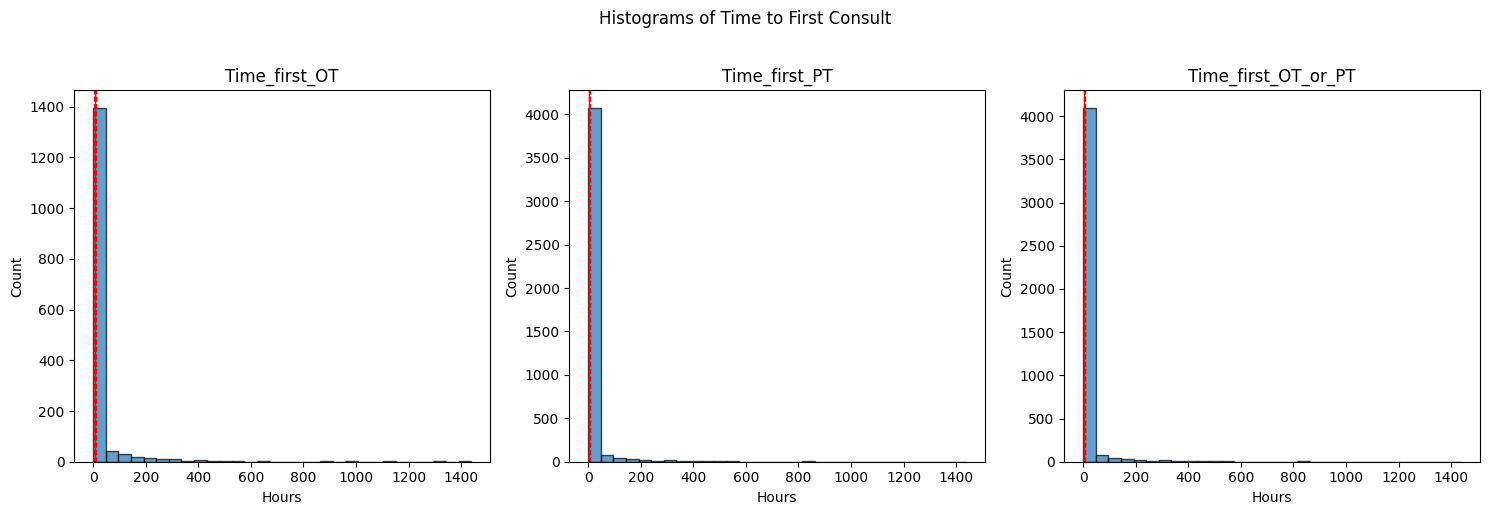

In [15]:
# First set: original variables, no cutoff
fig1, axes1 = plt.subplots(1, len(set1), figsize=(15, 5), sharey=False)

for ax, col in zip(axes1, set1):
    data = final_df_post_imv[col].dropna()
    ax.hist(data, bins=30, edgecolor="black", alpha=0.7)
    q1 = data.quantile(0.25)
    med = data.median()
    q3 = data.quantile(0.75)
    ax.axvline(q1, color="r", linestyle="--", linewidth=1)
    ax.axvline(med, color="r", linestyle="-",  linewidth=1)
    ax.axvline(q3, color="r", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("Hours")
    ax.set_ylabel("Count")

fig1.suptitle("Histograms of Time to First Consult", y=1.02)
plt.tight_layout()
fig1.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/graphs/post_imv_original_time_hist.png", dpi=300, bbox_inches="tight")
plt.show()

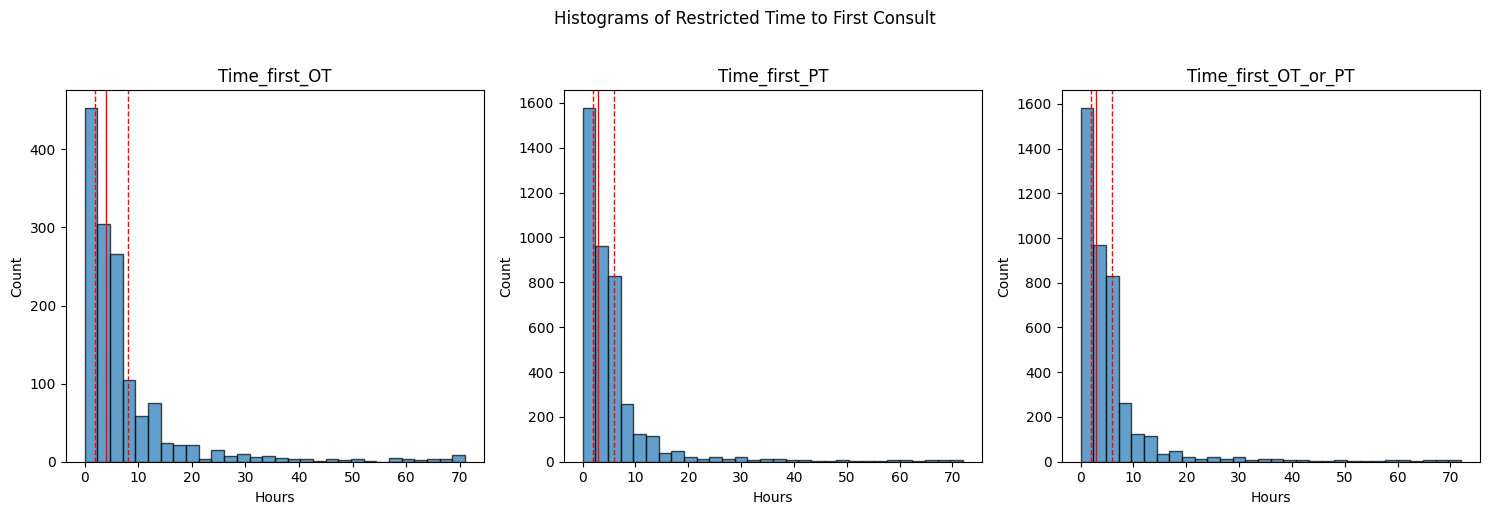

In [16]:
# First set: original variables, restrict to 0 - 72 hours
fig1, axes1 = plt.subplots(1, len(set1), figsize=(15, 5), sharey=False)

for ax, col in zip(axes1, set1):
    data = final_df_post_imv[col].dropna()
    data = data[(data >= -72) & (data <= 72)]
    ax.hist(data, bins=30, edgecolor="black", alpha=0.7)
    q1 = data.quantile(0.25)
    med = data.median()
    q3 = data.quantile(0.75)
    ax.axvline(q1, color="r", linestyle="--", linewidth=1)
    ax.axvline(med, color="r", linestyle="-",  linewidth=1)
    ax.axvline(q3, color="r", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("Hours")
    ax.set_ylabel("Count")

fig1.suptitle("Histograms of Restricted Time to First Consult", y=1.02)
plt.tight_layout()
fig1.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/graphs/72hr_time_hist.png", dpi=300, bbox_inches="tight")
plt.show()

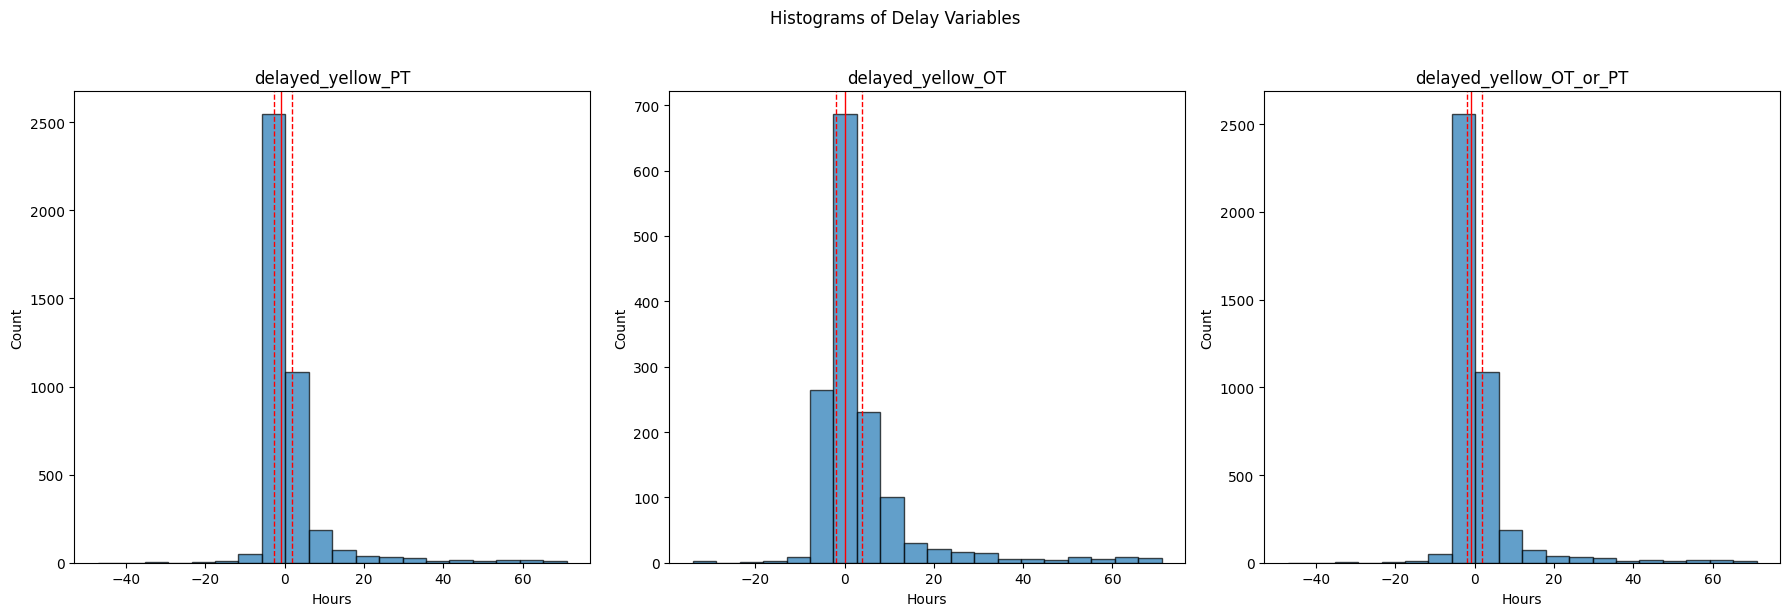

In [23]:
# Second set: delayed variables, no cutoff
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
axes2 = axes2.flatten()

for ax, col in zip(axes2, set2):
    data = final_df_post_imv[col].dropna()
    data = data[(data >= -72) & (data <= 72)]
    ax.hist(data, bins=20, edgecolor="black", alpha=0.7)
    q1 = data.quantile(0.25)
    med = data.median()
    q3 = data.quantile(0.75)
    ax.axvline(q1, color="r", linestyle="--", linewidth=1)
    ax.axvline(med, color="r", linestyle="-",  linewidth=1)
    ax.axvline(q3, color="r", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("Hours")
    ax.set_ylabel("Count")

fig2.suptitle("Histograms of Delay Variables", y=1.02)
plt.tight_layout()
fig2.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/graphs/post_imv_delayed_time_hist.png", dpi=300, bbox_inches="tight")
plt.show()

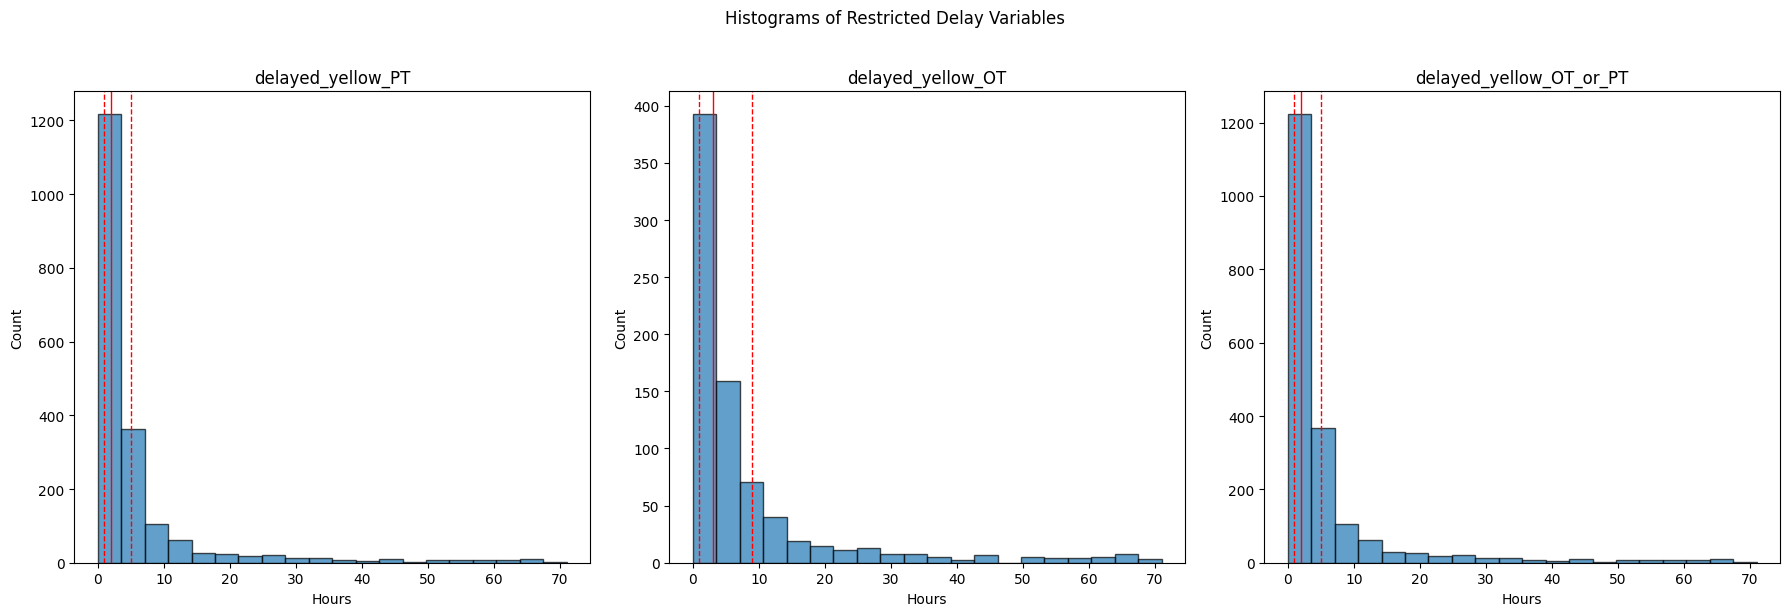

In [24]:
# Second set: delayed variables, restrict to 0 - 72 hours
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
axes2 = axes2.flatten()

for ax, col in zip(axes2, set2):
    data = final_df_post_imv[col].dropna()
    data = data[(data >= 0) & (data <= 72)]
    ax.hist(data, bins=20, edgecolor="black", alpha=0.7)
    q1 = data.quantile(0.25)
    med = data.median()
    q3 = data.quantile(0.75)
    ax.axvline(q1, color="r", linestyle="--", linewidth=1)
    ax.axvline(med, color="r", linestyle="-",  linewidth=1)
    ax.axvline(q3, color="r", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("Hours")
    ax.set_ylabel("Count")

fig2.suptitle("Histograms of Restricted Delay Variables", y=1.02)
plt.tight_layout()
fig2.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/graphs/72hr_delayed_time_hist.png", dpi=300, bbox_inches="tight")
plt.show()

## Boxplots for exposure variables

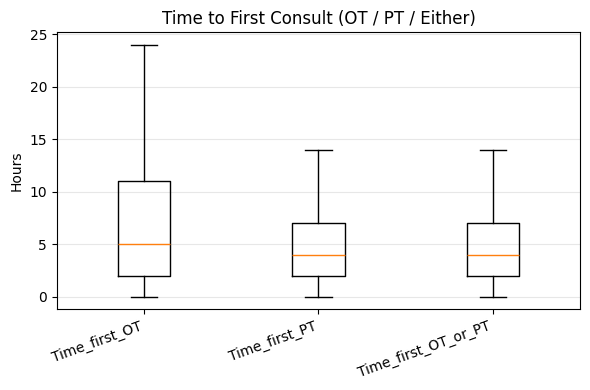

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

def boxplot_cols(ax, df, cols, title, ylabel="Hours", ylim=None):
    data = [df[c].dropna() for c in cols]
    ax.boxplot(data, showfliers=False) 
    ax.set_xticklabels(cols, rotation=20, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(axis="y", alpha=.3)
    plt.tight_layout()
    return ax

# Time to first consults 
boxplot_cols(ax, final_df_post_imv, set1, "Time to First Consult (OT / PT / Either)")
plt.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/graphs/time_to_first_consult_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

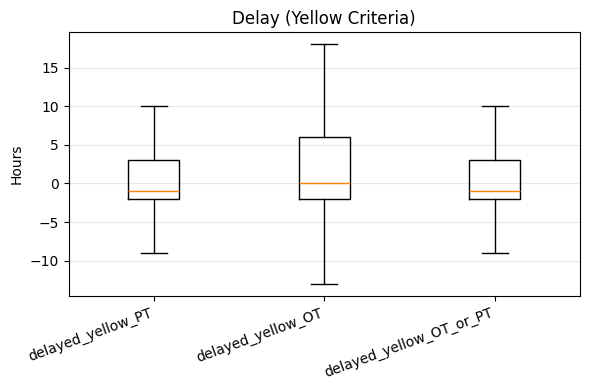

In [27]:
yellow_cols = ["delayed_yellow_PT", "delayed_yellow_OT", "delayed_yellow_OT_or_PT"]

fig, ax = plt.subplots(figsize=(6, 4))
boxplot_cols(ax, final_df_post_imv, yellow_cols, "Delay (Yellow Criteria)")
plt.tight_layout()
plt.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/graphs/delayed_time_boxplot_by_eligbility_criteria.png", dpi=300, bbox_inches="tight")
plt.show()

## CIF Plots with time to eligibility and time to consult time

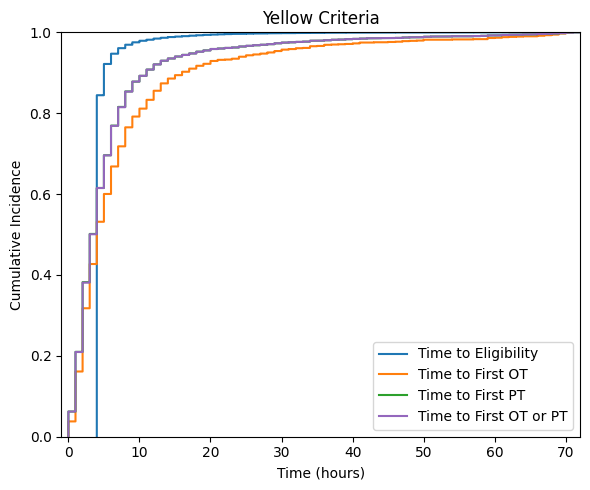

In [29]:
import numpy as np

def plot_cif(ax, series, label, color):
    data = series.dropna()
    data = data[(data >= 0) & (data <= 72)]
    x = np.sort(data.values)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where="post", label=label, color=color)

yellow_vars = [
    ("yellow_time_eligibility", "Time to Eligibility"),
    ("Time_first_OT", "Time to First OT"),
    ("Time_first_PT", "Time to First PT"),
    ("Time_first_OT_or_PT", "Time to First OT or PT"),
]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]

fig, ax = plt.subplots(figsize=(6, 5))

# Yellow criteria
for (col, label), color in zip(yellow_vars, colors):
    plot_cif(ax, final_df_post_imv[col], label, color)
ax.set_title("Yellow Criteria")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cumulative Incidence")
ax.set_xlim(-1, 72)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/graphs/cif_plot_by_eligibility_criteria", dpi=300, bbox_inches="tight")
plt.show()